<a href="https://colab.research.google.com/github/MuzaffarIshmurotov/German-Bank/blob/main/AUC_ROC_and_Gini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from sklearn.metrics import roc_auc_score

def calculate_gini(y_true, y_prob):
    # Using the correct function name: roc_auc_score
    auc = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    return gini

y_true = [0, 1, 1, 0]
y_prob = [0.1, 0.4, 0.35, 0.8]

print(f"Gini Coefficient: {calculate_gini(y_true, y_prob)}")

Gini Coefficient: 0.0


#### German credit scoring

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Fetch the German Credit dataset (dataset ID 31 on OpenML)
# Using as_frame=True to get a pandas DataFrame immediately
german_credit = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')

df = german_credit.frame
display(df.head())

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [5]:
df

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking,12,existing paid,furniture/equipment,1736,<100,4<=X<7,3,female div/dep/mar,none,...,real estate,31,none,own,1,unskilled resident,1,none,yes,good
996,<0,30,existing paid,used car,3857,<100,1<=X<4,4,male div/sep,none,...,life insurance,40,none,own,1,high qualif/self emp/mgmt,1,yes,yes,good
997,no checking,12,existing paid,radio/tv,804,<100,>=7,4,male single,none,...,car,38,none,own,1,skilled,1,none,yes,good
998,<0,45,existing paid,radio/tv,1845,<100,1<=X<4,4,male single,none,...,no known property,23,none,for free,1,skilled,1,yes,yes,bad


In [6]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [7]:
df.shape

(1000, 21)

In [8]:
display(df.head(5))

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [9]:
# To check for null values in the entire DataFrame:
df.isnull().sum()

,0
checking_status,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment,0
installment_commitment,0
personal_status,0
other_parties,0


Default Rate (Bad): 30.00%
Non-Default Rate (Good): 70.00%


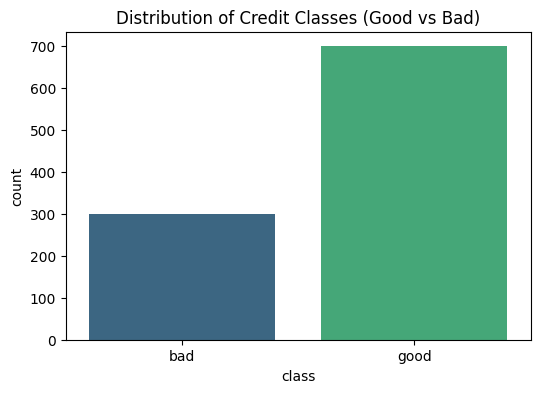

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the default rate percentage
# In the 'class' column, 'bad' indicates a default.
default_counts = df['class'].value_counts(normalize=True) * 100

print(f"Default Rate (Bad): {default_counts['bad']:.2f}%")
print(f"Non-Default Rate (Good): {default_counts['good']:.2f}%")

# Visualize the distribution
plt.figure(figsize=(6, 4))
# Updated to assign x to hue and set legend=False to resolve the FutureWarning
sns.countplot(x='class', data=df, hue='class', palette='viridis', legend=False)
plt.title('Distribution of Credit Classes (Good vs Bad)')
plt.show()

Default Rate by Purpose (Sorted by Risk):
purpose
education              44.000000
other                  41.666667
new car                38.034188
repairs                36.363636
business               35.051546
domestic appliance     33.333333
furniture/equipment    32.044199
radio/tv               22.142857
used car               16.504854
retraining             11.111111
Name: class, dtype: float64


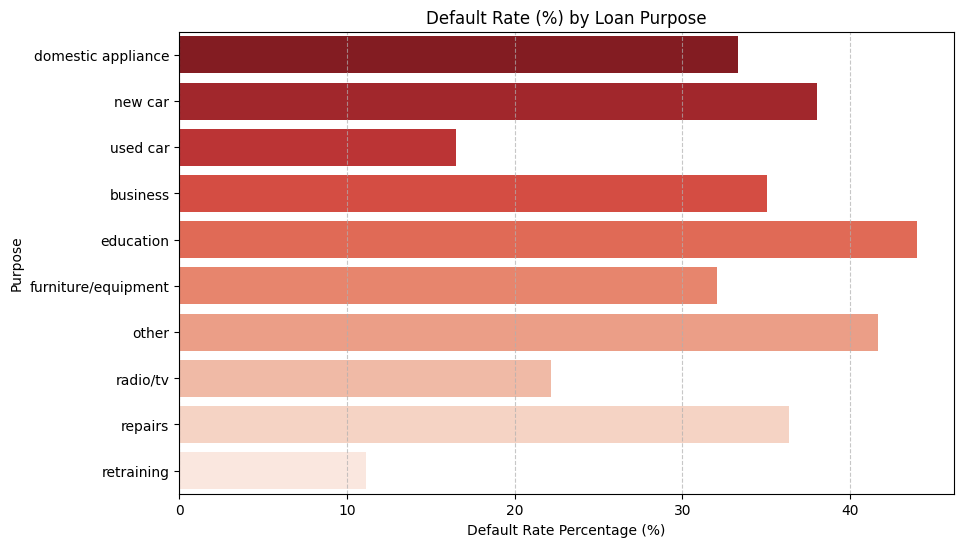

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the default rate for each purpose
# Added observed=False to resolve the pandas FutureWarning
purpose_risk = df.groupby('purpose', observed=False)['class'].apply(lambda x: (x == 'bad').mean() * 100).sort_values(ascending=False)

print("Default Rate by Purpose (Sorted by Risk):")
print(purpose_risk)

# Visualize the risk per purpose
plt.figure(figsize=(10, 6))
sns.barplot(x=purpose_risk.values, y=purpose_risk.index, hue=purpose_risk.index, palette='Reds_r', legend=False)
plt.title('Default Rate (%) by Loan Purpose')
plt.xlabel('Default Rate Percentage (%)')
plt.ylabel('Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

# The target column in this dataset is 'class', not 'default'
X = df.drop('class', axis=1)
y = df['class']

# Splitting the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (800, 20)
X_test shape: (200, 20)


In [13]:
# 1. Identify columns to fill
cols_to_fix = ['credit_amount', 'duration', 'age']

print("Missing values BEFORE filling:")
print(X_train[cols_to_fix].isnull().sum())

# 2. Calculate medians on TRAIN set only to avoid data leakage
medians = X_train[cols_to_fix].median()
print(f"\nCalculated Medians:\n{medians}")

# 3. Fill missing values in both Train and Test sets
for col in cols_to_fix:
    X_train[col] = X_train[col].fillna(medians[col])
    X_test[col] = X_test[col].fillna(medians[col])

print("\nMissing values AFTER filling:")
print(X_train[cols_to_fix].isnull().sum())

Missing values BEFORE filling:
credit_amount    0
duration         0
age              0
dtype: int64

Calculated Medians:
credit_amount    2246.5
duration           18.0
age                33.0
dtype: float64

Missing values AFTER filling:
credit_amount    0
duration         0
age              0
dtype: int64


In [14]:
print(f"Before encoding: {X_train.shape[1]} columns")

# 1. Encode X_train with drop_first=True to avoid the dummy variable trap
X_train = pd.get_dummies(X_train, drop_first=True)

# 2. Encode X_test
X_test = pd.get_dummies(X_test, drop_first=True)

# 3. Align X_test to X_train using reindex
# This ensures X_test has the same columns, filling missing ones with 0
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"After encoding:  {X_train.shape[1]} columns")

# Double check they match
print(f"Do columns match? {all(X_train.columns == X_test.columns)}")
display(X_train.head())

Before encoding: 20 columns
After encoding:  48 columns
Do columns match? True


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_<0,checking_status_>=200,checking_status_no checking,...,property_magnitude_car,other_payment_plans_none,other_payment_plans_stores,housing_own,housing_rent,job_unemp/unskilled non res,job_unskilled resident,job_skilled,own_telephone_yes,foreign_worker_yes
675,30,4530,4,4,26,1,1,False,False,True,...,True,True,False,False,True,False,False,False,True,True
703,30,2503,4,2,41,2,1,False,False,False,...,False,False,True,True,False,False,False,True,False,True
12,12,1567,1,1,22,1,1,False,False,False,...,True,True,False,True,False,False,False,True,True,True
845,21,3976,2,3,35,1,1,False,False,False,...,True,True,False,True,False,False,False,True,True,True
795,9,2301,2,4,22,1,1,False,False,True,...,False,True,False,False,True,False,False,True,False,True


In [15]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.metrics import roc_auc_score

In [16]:
# Convert y_train and y_test to numerical labels for SMOTE and metric calculation
# Assuming 'bad' is the positive class (1) and 'good' is the negative class (0)
y_train_encoded = y_train.map({'good': 0, 'bad': 1})
y_test_encoded = y_test.map({'good': 0, 'bad': 1})

# Print class counts before SMOTE
print("Class counts in y_train BEFORE SMOTE:")
print(y_train_encoded.value_counts())

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train_encoded)

# Print class counts after SMOTE
print("\nClass counts in y_train AFTER SMOTE:")
print(y_train_resampled.value_counts())

Class counts in y_train BEFORE SMOTE:
class
0    560
1    240
Name: count, dtype: int64

Class counts in y_train AFTER SMOTE:
class
1    560
0    560
Name: count, dtype: int64


In [17]:
import re

# XGBoost does not allow special characters like '<', '>', or '[' in feature names.
def sanitize_column_names(df):
    df.columns = [re.sub(r'[<>\\\[\\\]]', '_', col) for col in df.columns]
    return df

# Sanitize the resampled training set and the test set
X_train_resampled = sanitize_column_names(X_train_resampled)
X_test = sanitize_column_names(X_test)

# Train an XGBClassifier on the resampled data
xgb_model = xgb.XGBClassifier(random_state=42,  eval_metric='logloss')
xgb_model.fit(X_train_resampled, y_train_resampled)

# Predict probabilities on X_test
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate AUC-ROC
auc_roc = roc_auc_score(y_test_encoded, y_pred_proba)

# Calculate Gini coefficient
gini = 2 * auc_roc - 1

print(f"\nAUC-ROC: {auc_roc:.4f}")
print(f"Gini Coefficient: {gini:.4f}")


AUC-ROC: 0.7417
Gini Coefficient: 0.4833


Top 5 Most Important Features for Credit Risk:
checking_status_no checking           0.167228
housing_rent                          0.066236
checking_status__=200                 0.054865
credit_history_no credits/all paid    0.054096
other_parties_guarantor               0.036379
dtype: float32


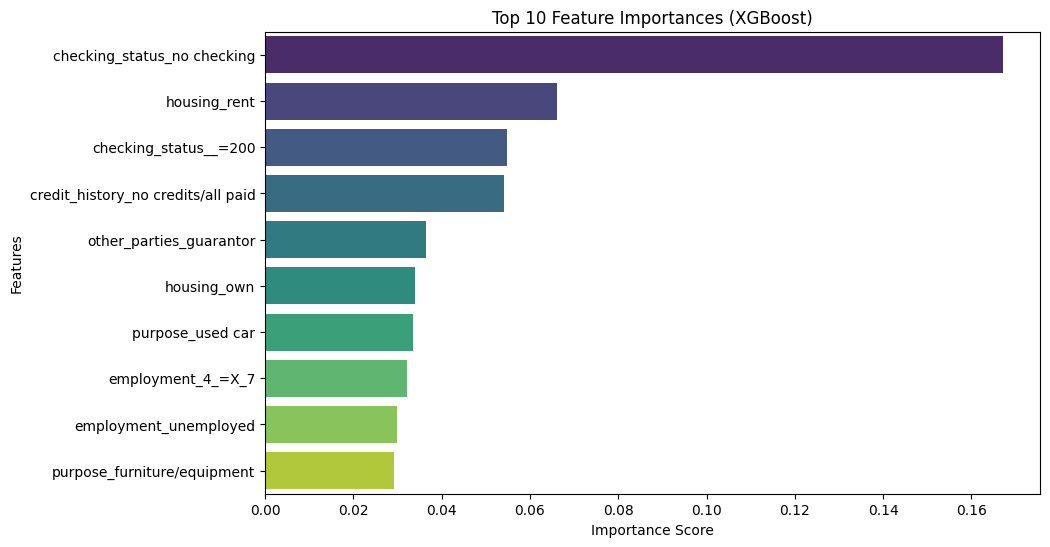

In [18]:
# Calculate feature importance scores
import pandas as pd

feature_importance = pd.Series(xgb_model.feature_importances_, index=X_train_resampled.columns).sort_values(ascending=False)

print("Top 5 Most Important Features for Credit Risk:")
print(feature_importance.head(5))

# Visualize the top 10 features for better context
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.head(10).values, y=feature_importance.head(10).index, hue=feature_importance.head(10).index, palette='viridis', legend=False)
plt.title('Top 10 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### Explanation of the Steps:

1.  **Target Variable Encoding**: The 'class' column (`y_train`, `y_test`) which contains 'good' and 'bad' labels, is converted into numerical format (`0` for 'good' and `1` for 'bad'). This is necessary because machine learning models and libraries like SMOTE typically work with numerical targets.

2.  **SMOTE (Synthetic Minority Over-sampling Technique)**:
    *   The original class distribution in `y_train_encoded` is printed, showing an imbalance (more 'good' than 'bad' instances).
    *   `SMOTE` is then applied to the `X_train` and `y_train_encoded` data. SMOTE works by creating synthetic samples for the minority class ('bad' loans in this case) based on its existing instances. This helps to balance the class distribution, preventing the model from being biased towards the majority class.
    *   The class distribution in `y_train_resampled` is printed again, demonstrating that the classes are now balanced.

3.  **XGBoost Classifier Training**: A `XGBClassifier` model is initialized and trained using the SMOTE-resampled training data (`X_train_resampled`, `y_train_resampled`). `random_state` is set for reproducibility, and `use_label_encoder=False` with `eval_metric='logloss'` are common parameters for modern XGBoost versions.

4.  **Probability Prediction**: The trained `xgb_model` is used to predict the probabilities of the 'bad' class (class `1`) for the `X_test` dataset. `predict_proba()` returns probabilities for both classes, and `[:, 1]` selects the probabilities for the positive class.

5.  **AUC-ROC Calculation**: The Area Under the Receiver Operating Characteristic (AUC-ROC) curve is calculated. AUC-ROC is a performance metric for classification problems at various threshold settings. It measures the area under the ROC curve, which plots the true positive rate against the false positive rate. A higher AUC-ROC (closer to 1) indicates better model performance.

6.  **Gini Coefficient Calculation**: The Gini coefficient is derived from the AUC-ROC score using the formula `2 * AUC - 1`. It is a common metric in credit scoring to evaluate the discriminative power of a model. A higher Gini coefficient (closer to 1) indicates better separation between the positive and negative classes.